# Métricas de Avaliação — Outras Métricas de Classificação
**Seção 3. Desempenho | Outras Métricas** · Home Credit Default Risk

Este notebook calcula **Acurácia, Precisão, Revocação (Recall) e F1-Score** usando as **fontes de dados reais do projeto**:

| Métrica | Fórmula | O que mede |
|---|---|---|
| **Acurácia** | (TP+TN) / (TP+FP+FN+TN) | % de predições corretas |
| **Precisão** | TP / (TP+FP) | dos previstos inadimplentes, quantos eram |
| **Revocação (Recall)** | TP / (TP+FN) | dos inadimplentes reais, quantos pegou |
| **F1-Score** | 2·(P·R)/(P+R) | média harmônica — ideal p/ base desbalanceada |

### 📂 Fontes de dados anexas (URLs embutidas — rodam direto)
- **`clean_data.csv`** — dados limpos com `TARGET` real (356.251 linhas; treino = TARGET 0/1, teste = TARGET vazio)
- **`submission.csv`** — probabilidades previstas no conjunto de teste (48.744 clientes)
- **`feature_importance.csv`** — importância por fold (`feature, importance, fold`)

> ⚠️ As 4 métricas exigem **rótulo real + predição juntos**. O `submission.csv` não tem o TARGET verdadeiro (é teste). Por isso, para gerar predições **com rótulo real**, treinamos um modelo com **validação cruzada (OOF)** sobre as linhas de `clean_data` que possuem TARGET, e aplicamos **thresholds** para converter probabilidade → classe.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)

pd.set_option("display.float_format", lambda v: f"{v:0.4f}")
plt.rcParams["figure.figsize"] = (8, 4)

# ---- URLs das fontes de dados anexas do projeto ----
URL_CLEAN = "clean_data.csv"   # clean_data.csv
URL_SUB   = "submission.csv"   # submission.csv
URL_FI    = "feature_importance.csv"   # feature_importance.csv

## 1. Carregar as fontes anexas


In [2]:
clean = pd.read_csv(URL_CLEAN)
sub   = pd.read_csv(URL_SUB)
fi    = pd.read_csv(URL_FI)

print(f"clean_data : {clean.shape[0]:,} linhas x {clean.shape[1]} colunas")
print(f"submission : {sub.shape[0]:,} linhas")
print(f"feat_imp   : {fi.shape[0]:,} linhas (formato longo: feature/importance/fold)")

# linhas com TARGET conhecido = conjunto de TREINO (onde podemos avaliar métricas)
train = clean[clean["TARGET"].notna()].copy()
train["TARGET"] = train["TARGET"].astype(int)
print(f"\nLinhas com TARGET real (treino): {len(train):,}")
print(f"Taxa de inadimplência real     : {train['TARGET'].mean():.4f}  (~{train['TARGET'].mean()*100:.2f}%)")

clean_data : 356,251 linhas x 122 colunas
submission : 48,744 linhas
feat_imp   : 1,730 linhas (formato longo: feature/importance/fold)

Linhas com TARGET real (treino): 307,507
Taxa de inadimplência real     : 0.0807  (~8.07%)


## 2. Gerar predições com rótulo real (OOF)

Treinamos um **LightGBM** com **StratifiedKFold (5)**. Cada cliente recebe uma probabilidade prevista por um modelo que **não o viu no treino** (out-of-fold) — assim a avaliação é honesta. Usamos apenas as colunas numéricas para um pipeline reprodutível e rápido.


In [3]:
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier

# features numéricas (exclui ids e alvo)
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
for c in ["SK_ID_CURR", "TARGET"]:
    if c in num_cols: num_cols.remove(c)

X = train[num_cols]
y = train["TARGET"].values

# amostragem opcional para acelerar (use frac=1.0 para base completa)
FRAC = 0.30
if FRAC < 1.0:
    samp = train.sample(frac=FRAC, random_state=42).index
    Xs, ys = train.loc[samp, num_cols], train.loc[samp, "TARGET"].values
    print(f"Amostra usada: {len(ys):,} clientes ({FRAC:.0%}) — ajuste FRAC=1.0 para base completa")
else:
    Xs, ys = X, y

oof = np.zeros(len(ys))
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = dict(n_estimators=300, learning_rate=0.05, num_leaves=34,
              subsample=0.9, colsample_bytree=0.9, objective="binary", n_jobs=-1, verbose=-1)

for k, (tr, va) in enumerate(folds.split(Xs, ys), 1):
    clf = LGBMClassifier(**params)
    clf.fit(Xs.iloc[tr], ys[tr])
    oof[va] = clf.predict_proba(Xs.iloc[va])[:, 1]
    print(f"Fold {k} ok")

print(f"\nAUC (OOF): {roc_auc_score(ys, oof):.4f}")

# guarda para as métricas
y_true, y_prob = ys, oof

Amostra usada: 92,252 clientes (30%) — ajuste FRAC=1.0 para base completa


Fold 1 ok


Fold 2 ok


Fold 3 ok


Fold 4 ok


Fold 5 ok

AUC (OOF): 0.7444


## 3. Métricas por threshold (Acurácia, Precisão, Recall, F1)
Convertendo probabilidade em classe: `previsto = 1 se prob >= threshold`.


In [4]:
def metricas(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {"threshold": threshold, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "Acuracia": accuracy_score(y_true, y_pred),
            "Precisao": precision_score(y_true, y_pred, zero_division=0),
            "Recall":   recall_score(y_true, y_pred, zero_division=0),
            "F1":       f1_score(y_true, y_pred, zero_division=0)}

grid = [0.50, 0.30, 0.20, 0.15, 0.10, 0.08, 0.05]
tab = pd.DataFrame([metricas(y_true, y_prob, t) for t in grid])
tab[["threshold","TP","FP","FN","TN","Acuracia","Precisao","Recall","F1"]]

,threshold,TP,FP,FN,TN,Acuracia,Precisao,Recall,F1
0,0.5000,138,142,7304,84668,0.9193,0.4929,0.0185,0.0357
1,0.3000,926,1725,6516,83085,0.9107,0.3493,0.1244,0.1835
2,0.2000,2015,5241,5427,79569,0.8844,0.2777,0.2708,0.2742
3,0.1500,2929,9275,4513,75535,0.8505,0.2400,0.3936,0.2982
4,0.1000,4189,17868,3253,66942,0.7711,0.1899,0.5629,0.2840
5,0.0800,4836,24213,2606,60597,0.7093,0.1665,0.6498,0.2651
6,0.0500,5988,40478,1454,44332,0.5455,0.1289,0.8046,0.2222


## 4. Threshold que maximiza o F1-Score
Em base desbalanceada (~8%), o corte 0,5 raramente é o melhor.


Melhor threshold (max F1): 0.140
  Acurácia 0.8396 | Precisão 0.2306 | Recall 0.4229 | F1 0.2984


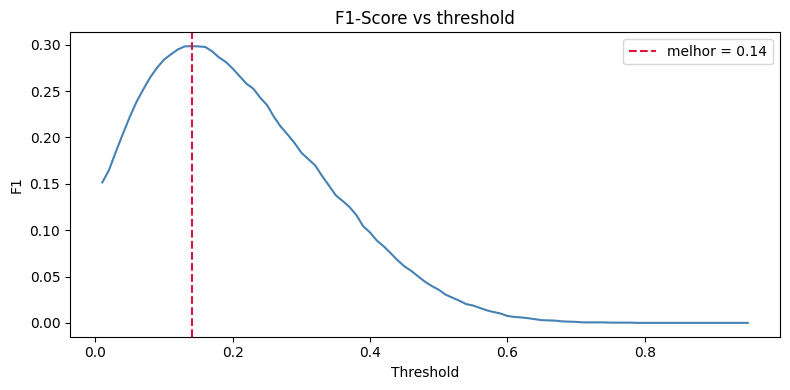

In [5]:
ths = np.linspace(0.01, 0.95, 95)
f1s = [f1_score(y_true, (y_prob>=t).astype(int), zero_division=0) for t in ths]
best_t = ths[int(np.argmax(f1s))]
m = metricas(y_true, y_prob, best_t)
print(f"Melhor threshold (max F1): {best_t:.3f}")
print(f"  Acurácia {m['Acuracia']:.4f} | Precisão {m['Precisao']:.4f} | Recall {m['Recall']:.4f} | F1 {m['F1']:.4f}")

plt.plot(ths, f1s, color="steelblue")
plt.axvline(best_t, color="crimson", ls="--", label=f"melhor = {best_t:.2f}")
plt.title("F1-Score vs threshold"); plt.xlabel("Threshold"); plt.ylabel("F1")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Matriz de confusão e relatório (no melhor threshold)


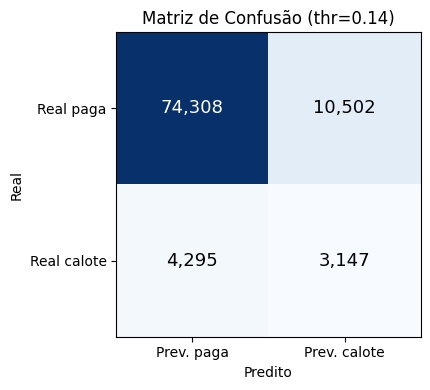

              precision    recall  f1-score   support

    Paga (0)       0.95      0.88      0.91     84810
  Calote (1)       0.23      0.42      0.30      7442

    accuracy                           0.84     92252
   macro avg       0.59      0.65      0.60     92252
weighted avg       0.89      0.84      0.86     92252



In [6]:
y_pred = (y_prob >= best_t).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[0,1])

fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Prev. paga","Prev. calote"]); ax.set_yticklabels(["Real paga","Real calote"])
ax.set_xlabel("Predito"); ax.set_ylabel("Real"); ax.set_title(f"Matriz de Confusão (thr={best_t:.2f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                color="white" if cm[i,j]>cm.max()/2 else "black", fontsize=13)
plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred, target_names=["Paga (0)","Calote (1)"], zero_division=0))

## 6. Validação cruzada com o `submission.csv` (distribuição do teste)

O `submission.csv` é o conjunto de **teste** (sem rótulo). Mesmo sem TARGET, comparamos a **distribuição** das probabilidades de teste vs. as predições OOF de treino — se forem semelhantes, há **consistência treino↔teste** (sem drift grosseiro).


Probabilidade média — OOF (treino): 0.0785
Probabilidade média — submission (teste): 0.0747


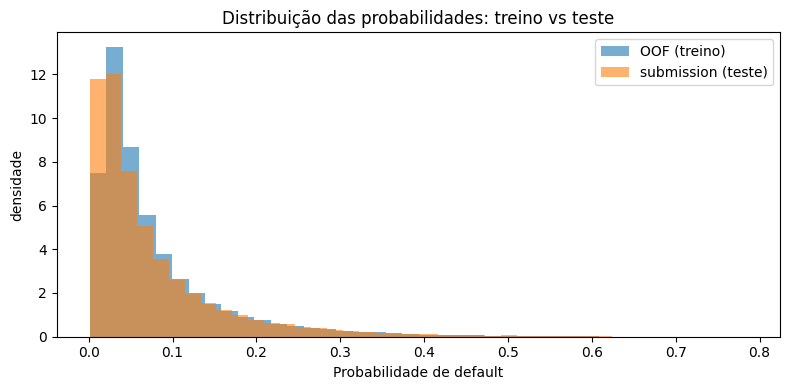

In [7]:
print("Probabilidade média — OOF (treino):", round(float(np.mean(y_prob)),4))
print("Probabilidade média — submission (teste):", round(float(sub['TARGET'].mean()),4))

plt.hist(y_prob, bins=40, alpha=0.6, density=True, label="OOF (treino)")
plt.hist(sub["TARGET"], bins=40, alpha=0.6, density=True, label="submission (teste)")
plt.title("Distribuição das probabilidades: treino vs teste")
plt.xlabel("Probabilidade de default"); plt.ylabel("densidade")
plt.legend(); plt.tight_layout(); plt.show()

## 7. Contexto: features mais importantes (feature_importance.csv)

Consolidamos o arquivo (formato longo) por **média entre folds** + **estabilidade (cv = std/mean)**, dando contexto a *quais variáveis* dirigem as predições que estamos avaliando.


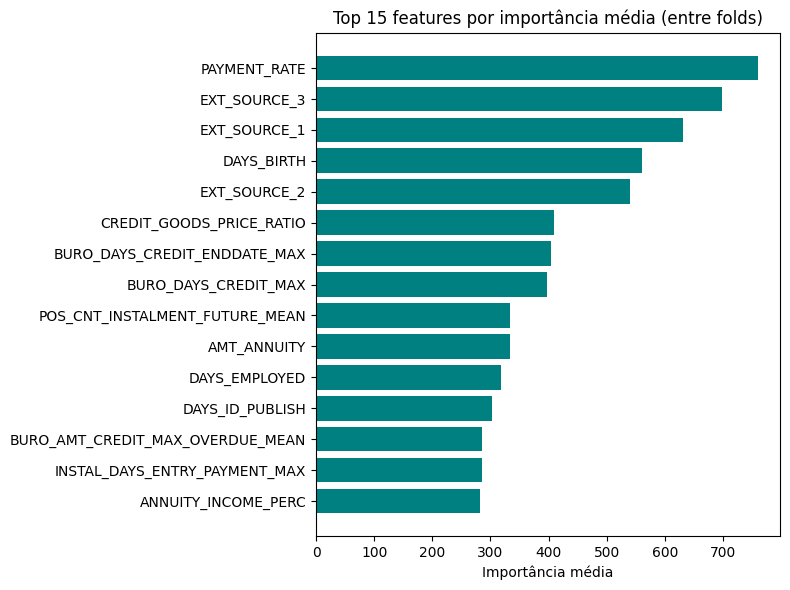

Top 10 (importância média + estabilidade):


'                       feature     mean     cv\n                  PAYMENT_RATE 760.2000 0.0497\n                  EXT_SOURCE_3 698.6000 0.1057\n                  EXT_SOURCE_1 631.6000 0.0656\n                    DAYS_BIRTH 560.2000 0.0328\n                  EXT_SOURCE_2 539.6000 0.1095\n      CREDIT_GOODS_PRICE_RATIO 409.4000 0.0872\n  BURO_DAYS_CREDIT_ENDDATE_MAX 404.8000 0.0997\n          BURO_DAYS_CREDIT_MAX 396.6000 0.0811\nPOS_CNT_INSTALMENT_FUTURE_MEAN 334.4000 0.0787\n                   AMT_ANNUITY 333.6000 0.1007'

In [8]:
agg = (fi.groupby("feature")["importance"]
         .agg(["mean","std"]).reset_index())
agg["cv"] = agg["std"] / agg["mean"].replace(0, np.nan)
top = agg.sort_values("mean", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top["feature"][::-1], top["mean"][::-1], color="teal")
ax.set_title("Top 15 features por importância média (entre folds)")
ax.set_xlabel("Importância média"); plt.tight_layout(); plt.show()

print("Top 10 (importância média + estabilidade):")
top[["feature","mean","cv"]].head(10).to_string(index=False)

## 8. Interpretação para o negócio

- **Acurácia** isolada **engana** em base desbalanceada (~8%): "todos pagam" já daria ~92%.
- **Recall** é o KPI crítico em crédito: % de inadimplentes que o modelo **pega** — recall baixo = calotes despercebidos (perda).
- **Precisão**: dos sinalizados, quantos eram risco — precisão baixa = bons clientes recusados.
- **F1-Score** equilibra os dois → útil para definir o **threshold operacional**.
- **Trade-off:** baixar o threshold ↑ Recall mas ↓ Precisão. A escolha é uma **decisão de negócio**.

> A métrica-mestra do projeto continua sendo o **AUC** (independe de threshold); estas métricas **traduzem** o modelo em uma política de decisão concreta.
